In [1]:
import sys
import os
import cv2
from tqdm import tqdm
from pathlib import Path
from typing import Dict, List, Tuple, Optional

PROJECT_ROOT1 = Path("/home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5")
PROJECT_ROOT2 = Path("/media")
sys.path.insert(0, str(PROJECT_ROOT1))
sys.path.insert(0, str(PROJECT_ROOT2))

# ---------------------------------------------------------------------
# TMPDIR for multiprocessing / tempfile
# ---------------------------------------------------------------------
import tempfile

TMP_DIR = Path("/media/general_storage6/rmastorage/tmp_aux")
TMP_DIR.mkdir(parents=True, exist_ok=True)

os.environ["TMPDIR"] = str(TMP_DIR)
os.environ["TEMP"] = str(TMP_DIR)
os.environ["TMP"] = str(TMP_DIR)

tempfile.tempdir = str(TMP_DIR)

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, average_precision_score

import torch
from torch.utils.data import DataLoader

from models.doc_forgery_dataset_rgb_rtm import DocForgeryDataset
from models.dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm.model_dual_branch_segformer_b2_mmseg_rgb_with_convs_rtm import SegFormerRGBRunner    # change
from models.torchtools.torch_collate_segformer_b2_rgb_rtm import pad_collate

from tensorboard.backend.event_processing import event_accumulator

/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/iss

In [2]:
# ============================================================
# Configuration
# ============================================================

EXP_NAME = "VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm"  # change
EXP_NAME_TRAIN = "TRAIN/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/training_metric_plots"    # change

TRAIN_OUT_ROOT = Path("/home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo") / EXP_NAME_TRAIN
TRAIN_PLOTS_DIR = TRAIN_OUT_ROOT / "training_metric_plots"
TRAIN_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

CKPT = (
    PROJECT_ROOT2
    #/ "models"
    #/ "weights_segformer_b2_rtm_several_inputs"
    #/ "media"
    / "generalstorage5" 
    / "dual_branch_weights_mmseg_segformer_b2_rgb_with_convs_rtm_corretoo"
    / "dual_branch-mmseg-segformer_b2-rgb-with-convs"
    / "2026-05-15 17:22:33.101590-checkpoint72.pth"
)  # change

BACKBONE_CKPT = (
    PROJECT_ROOT1
    / "models"
    / "RTMSegformer"
    / "configs"
    / "segformer"
    / "pretrain"
    / "mit_b2.pth"
)

VAL_IMG_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/val_v2/JPEGImages"
VAL_MASK_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/val_v2/SegmentationClass"

TEST_IMG_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/test_v2/JPEGImages"
TEST_MASK_DIR = "/media/general_storage6/rmastorage/datasets/RealTextManipulation/test_v2/SegmentationClass"

RUN_DIR = (
    PROJECT_ROOT1
    #/ "models"
    #/ "runs_segformer_b2_rtm_several_inputs"
    / "dual_branch_runs_mmseg_segformer_b2_rgb_with_convs_rtm_corretoo"
    / "dual_branch-mmseg-segformer_b2-rgb-with-convs"
)  # change

BATCH_SIZE = 32
NUM_WORKERS = 8
QF3 = 90

# 0-19 epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 0
#EPOCH_MAX = 20

# 20-49 epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 20
#EPOCH_MAX = 50

# 50-99 epochs
EPOCH_OFFSET = 0
EPOCH_MIN = 50
EPOCH_MAX = 69

# All epochs
#EPOCH_OFFSET = 0
#EPOCH_MIN = 0
#EPOCH_MAX = 88

DEVICE = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

print("TRAIN_PLOTS_DIR:", TRAIN_PLOTS_DIR)
print("DEVICE:", DEVICE)

TRAIN_PLOTS_DIR: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/TRAIN/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/training_metric_plots/training_metric_plots
DEVICE: cuda:3


In [3]:
# =============================================================================
# Output folders
# =============================================================================

OUT_ROOT = (
    PROJECT_ROOT1
    / "models"
    / "eval_outputs_corretoo"
    / EXP_NAME
)  # change
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DIR_MASKS = OUT_ROOT / "pred_masks"
DIR_TABLE = OUT_ROOT / "tables"
DIR_PLOTS = OUT_ROOT / "plots"
DIR_CMS   = OUT_ROOT / "confusion_matrices"

for folder in [DIR_MASKS, DIR_TABLE, DIR_PLOTS, DIR_CMS]:
    folder.mkdir(parents=True, exist_ok=True)

print("OUT_ROOT:", OUT_ROOT)

OUT_ROOT: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm


In [4]:
# =============================================================================
# Load checkpoint
# =============================================================================

ckpt = torch.load(CKPT, map_location="cpu")

THR_PIX = float(ckpt.get("best_thr_pix", ckpt.get("best_thr", 0.5)))
THR_IMG = float(ckpt.get("best_thr_img", 0.5))

print("Checkpoint best_thr_pix:", THR_PIX)
print("Checkpoint best_thr_img:", THR_IMG)

Checkpoint best_thr_pix: 0.023224489763379097
Checkpoint best_thr_img: 0.1599999964237213


In [5]:
# =============================================================================
# Dataset and dataloader creation
# =============================================================================

def build_dataset(image_dir: str, mask_dir: str) -> DocForgeryDataset:
    """Create a dataset with the same preprocessing used during evaluation."""
    
    dataset = DocForgeryDataset(
        images_repo=[Path(image_dir)],
        masks_repo=[Path(mask_dir)],
        crop_size=(512, 512),
        grid_crop=True,
        seed=3,
        balance_crops=False,
        stride=512,
        use_augs=False,
        verbose_stats=True,
    )

    dataset.use_augs = False
    dataset.QF = QF3
    return dataset


def build_loader(dataset: DocForgeryDataset) -> DataLoader:
    """Create a dataloader with the custom padding collate function."""
    
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=lambda batch: pad_collate(batch, ignore_index=-1),
    )


ds_val = build_dataset(VAL_IMG_DIR, VAL_MASK_DIR)
ds_test = build_dataset(TEST_IMG_DIR, TEST_MASK_DIR)

dl_val = build_loader(ds_val)
dl_test = build_loader(ds_test)

print("VAL windows:", len(ds_val))
print("TEST windows:", len(ds_test))

[INFO] docs=900 windows=7033 pos=1771 neg=5262 balance_crops=False p_pos_crop=0.5 stride=512
[INFO] docs=900 windows=7120 pos=1743 neg=5377 balance_crops=False p_pos_crop=0.5 stride=512
VAL windows: 7033
TEST windows: 7120


In [6]:
# ============================================================
# Load model
# ============================================================

runner = SegFormerRGBRunner(
    load_path=CKPT,
)

runner.model.to(DEVICE)
runner.model.eval()

print("Model loaded on:", DEVICE)

/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/mmseg/models/decode_heads/decode_head.py:136: UserWarning: threshold is not defined for binary, and defaultsto 0.3
  warnings.warn('threshold is not defined for binary, and defaults'
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/mmseg/models/builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
/home/guests3/rma/.conda/envs/rtm/lib/python3.8/site-packages/mmseg/models/losses/cross_entropy_loss.py:235: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


[mit_b2] Loaded backbone-only weights. missing=0 unexpected=0
... Loading trained weights
Done.
Model loaded on: cuda:3


In [7]:
# =============================================================================
# Basic metric helpers
# =============================================================================

TAMP_PREFIXES = {"cpmv", "insert", "splice", "edit", "inpaint", "cover"}
GOOD_PREFIXES = {"good"}


def group_from_stem(stem: str) -> str:
    """Map each image filename to its evaluation group."""
    
    prefix = stem.split("_")[0]

    if prefix in TAMP_PREFIXES:
        return "tamp"

    if prefix in GOOD_PREFIXES:
        return "good"


def get_doc_ids_from_batch(batch: dict) -> List[str]:
    """Extract document identifiers from a batch."""
    
    if "doc_id" in batch:
        return [str(doc_id) for doc_id in batch["doc_id"]]

    if "meta" in batch:
        return [str(meta["stem"]) for meta in batch["meta"]]

    raise KeyError("Batch must contain either 'doc_id' or 'meta' with document stems.")

In [8]:
# ============================================================
# Label utilities
# ============================================================

@torch.no_grad()
def image_labels_from_mask(
    labels_mask: torch.Tensor,
    ignore_index: int = -1,
) -> torch.Tensor:
    """Derive one image-level label per crop from the corresponding segmentation mask."""
    
    if labels_mask.dim() == 4:
        mask = labels_mask.squeeze(1)
    else:
        mask = labels_mask

    valid = mask != ignore_index
    tampered = (mask == 1) & valid

    return tampered.flatten(1).any(dim=1).float()


def sigmoid_scalar(value: float) -> float:
    """Compute the sigmoid of a scalar value."""
    
    return float(1.0 / (1.0 + np.exp(-value)))


def compute_binary_metrics(
    y_true: List[bool],
    y_pred: List[bool],
    eps: float = 1e-8,
) -> dict:
    """Compute binary classification metrics from boolean targets and predictions."""
    
    tp = sum(pred and true for pred, true in zip(y_pred, y_true))
    fp = sum(pred and not true for pred, true in zip(y_pred, y_true))
    fn = sum((not pred) and true for pred, true in zip(y_pred, y_true))
    tn = sum((not pred) and (not true) for pred, true in zip(y_pred, y_true))

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)

    tpr = tp / (tp + fn + eps)
    tnr = tn / (tn + fp + eps)
    bal_acc = 0.5 * (tpr + tnr)

    return {
        "n_docs": len(y_true),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "acc": acc,
        "bal_acc": bal_acc,
    }

In [9]:
# ============================================================
# Collect document-level classification scores
# ============================================================

@torch.no_grad()
def collect_document_scores_and_labels(
    model: SegFormerRGBRunner,
    dataloader: DataLoader,
    device: torch.device,
    ignore_index: int = -1,
) -> Tuple[Dict[str, dict], Dict[str, bool], Dict[str, str]]:
    """Collect classification scores grouped by document."""
    
    doc_scores = {}
    doc_targets = {}
    doc_groups = {}

    model.model.eval()

    for batch in dataloader:
        output = model.logits(
            batch,
            device,
            loss_fn=None,
        )

        cls_logit = getattr(output, "cls_logit", None)
        if cls_logit is None:
            raise RuntimeError("ModelOutput does not contain 'cls_logit'.")

        labels = output.labels
        cls_prob_crop = torch.sigmoid(cls_logit.view(-1))

        crop_targets = image_labels_from_mask(
            labels_mask=labels,
            ignore_index=ignore_index,
        )

        doc_ids = get_doc_ids_from_batch(batch)

        for idx, doc_id in enumerate(doc_ids):
            doc_id = str(doc_id)

            cls_score = float(cls_prob_crop[idx].detach().cpu().item())
            cls_pred = bool(cls_score >= THR_IMG)
            target_value = bool(crop_targets[idx].detach().cpu().item())

            if doc_id not in doc_scores:
                doc_scores[doc_id] = {
                    "cls_scores": [],
                    "cls_preds": [],
                }

            doc_scores[doc_id]["cls_scores"].append(cls_score)
            doc_scores[doc_id]["cls_preds"].append(cls_pred)

            doc_targets[doc_id] = bool(doc_targets.get(doc_id, False) or target_value)
            doc_groups.setdefault(doc_id, group_from_stem(doc_id))

    return doc_scores, doc_targets, doc_groups


def aggregate_scores(
    values: List[float],
    aggregation: str = "max",
) -> float:
    """Aggregate crop scores into one document score."""
    
    if len(values) == 0:
        return 0.0

    if aggregation == "max":
        return float(max(values))

    if aggregation == "mean":
        return float(sum(values) / len(values))

    raise ValueError("aggregation must be either 'max' or 'mean'.")


def build_document_score_table(
    doc_scores_raw: Dict[str, dict],
    doc_targets: Dict[str, bool],
    doc_groups: Dict[str, str],
    aggregation: str = "max",
) -> pd.DataFrame:
    """Build a document-level table with classification score and target values."""
    
    rows = []

    for doc_id, score_dict in doc_scores_raw.items():
        cls_doc_score = aggregate_scores(score_dict["cls_scores"], aggregation=aggregation)
        cls_doc_pred = bool(any(score_dict["cls_preds"]))

        rows.append(
            {
                "doc_id": doc_id,
                "group": doc_groups.get(doc_id, "tamp"),
                "target": bool(doc_targets.get(doc_id, False)),
                "score_cls": float(cls_doc_score),
                "pred_cls": cls_doc_pred,
            }
        )

    return pd.DataFrame(rows)

In [10]:
# ============================================================
# Evaluation using checkpoint image-level threshold
# ============================================================

def evaluate_cls_only(
    df_test: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    """Evaluate cls_only document-level predictions using a fixed threshold."""
    
    rows = []

    for split_name, group_name in [("tamp", "tamp"), ("all", None)]:
        if group_name is None:
            df_eval = df_test.copy()
        else:
            df_eval = df_test[df_test["group"] == group_name].copy()

        y_true = df_eval["target"].astype(bool).tolist()
        y_pred = df_eval["pred_cls"].astype(bool).tolist()

        metrics = compute_binary_metrics(
            y_true=y_true,
            y_pred=y_pred,
        )

        row = {
            "split": split_name,
            "threshold": float(threshold),
        }
        row.update(metrics)
        rows.append(row)

    return pd.DataFrame(rows)

In [11]:
# ============================================================
# Test evaluation
# ============================================================

print("\nCollecting test document scores...")

test_doc_scores_raw, test_doc_targets, test_doc_groups = collect_document_scores_and_labels(
    model=runner,
    dataloader=dl_test,
    device=DEVICE,
    ignore_index=-1,
)

df_test_doc = build_document_score_table(
    doc_scores_raw=test_doc_scores_raw,
    doc_targets=test_doc_targets,
    doc_groups=test_doc_groups,
    aggregation="max",
)

print("Test documents:", len(df_test_doc))

report_df = evaluate_cls_only(
    df_test=df_test_doc,
    threshold=THR_IMG,
)

print(report_df)

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.

Test documents: 900
  split  threshold  n_docs   tp   fp  fn   tn  precision    recall        f1  \
0  tamp       0.16     600  547    0  53    0   1.000000  0.911667  0.953792   
1   all       0.16     900  547  136  53  164   0.800878  0.911667  0.852689   

        acc   bal_acc  
0  0.911667  0.455833  
1  0.790000  0.729167  


In [12]:
def save_csv_and_png_table(
    df: pd.DataFrame,
    out_dir: Path,
    csv_name: str,
    png_name: str,
    decimals: int = 4,
    title: Optional[str] = None,
) -> Tuple[Path, Path]:
    """Save a DataFrame as both a CSV file and a PNG table."""
    
    out_dir.mkdir(parents=True, exist_ok=True)

    csv_path = out_dir / csv_name
    df.to_csv(csv_path, index=False)

    df_fmt = df.copy()

    for column in df_fmt.columns:
        if pd.api.types.is_numeric_dtype(df_fmt[column]):
            df_fmt[column] = df_fmt[column].map(lambda value: f"{value:.{decimals}f}")

    n_rows, n_cols = df_fmt.shape

    fig_width = min(22, 1.4 + 1.1 * n_cols)
    fig_height = max(3.0, 0.8 + 0.45 * n_rows)

    fig, ax = plt.subplots(
        figsize=(fig_width, fig_height),
        dpi=220,
    )

    ax.axis("off")

    table = ax.table(
        cellText=df_fmt.values,
        colLabels=df_fmt.columns.tolist(),
        cellLoc="center",
        colLoc="center",
        loc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.5)

    for col_idx in range(n_cols):
        cell = table[0, col_idx]
        cell.set_text_props(weight="bold")
        cell.set_linewidth(1.0)

    for row_idx in range(1, n_rows + 1):
        for col_idx in range(n_cols):
            table[row_idx, col_idx].set_linewidth(0.8)

    if title is not None:
        ax.set_title(title, fontsize=12, pad=12)

    png_path = out_dir / png_name

    plt.tight_layout()
    plt.savefig(
        png_path,
        bbox_inches="tight",
    )
    plt.close(fig)

    return csv_path, png_path

In [13]:
# ================================================================
# Save document-level metrics
# ================================================================

csv_path, png_path = save_csv_and_png_table(
    df=report_df,
    out_dir=DIR_TABLE,
    csv_name="test_document_level_metrics.csv",
    png_name="test_document_level_metrics.png",
    title="TEST — Document-level metrics",
)

print("Saved:", csv_path)
print("Saved:", png_path)

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_document_level_metrics.csv
Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_document_level_metrics.png


In [14]:
# ============================================================
# AUC and threshold-dependent evaluation table
# ============================================================

def recall_at_fpr(
    y_true: np.ndarray,
    scores: np.ndarray,
    target_fpr: float,
) -> float:
    """Compute the maximum recall obtained with FPR below a target value."""
    
    if len(np.unique(y_true)) < 2:
        return float("nan")

    fpr, tpr, _ = roc_curve(y_true, scores)

    valid = fpr <= target_fpr
    if not np.any(valid):
        return 0.0

    return float(np.max(tpr[valid]))


def compute_auc_metrics(
    y_true: np.ndarray,
    scores: np.ndarray,
) -> dict:
    """Compute threshold-independent document-level metrics."""
    
    if len(np.unique(y_true)) < 2:
        return {
            "ROC_AUC": float("nan"),
            "PR_AUC": float("nan"),
            "Recall@FPR=1%": float("nan"),
            "Recall@FPR=5%": float("nan"),
            "Recall@FPR=10%": float("nan"),
        }

    fpr, tpr, _ = roc_curve(y_true, scores)

    return {
        "ROC_AUC": float(auc(fpr, tpr)),
        "PR_AUC": float(average_precision_score(y_true, scores)),
        "Recall@FPR=1%": recall_at_fpr(y_true, scores, 0.01),
        "Recall@FPR=5%": recall_at_fpr(y_true, scores, 0.05),
        "Recall@FPR=10%": recall_at_fpr(y_true, scores, 0.10),
    }


def compute_threshold_metrics_from_scores(
    y_true: np.ndarray,
    scores: np.ndarray,
    threshold: float,
    eps: float = 1e-8,
) -> dict:
    """Compute threshold-dependent binary metrics from continuous scores."""
    
    y_true = y_true.astype(bool)
    y_pred = scores >= threshold

    tp = np.logical_and(y_pred, y_true).sum()
    fp = np.logical_and(y_pred, ~y_true).sum()
    fn = np.logical_and(~y_pred, y_true).sum()
    tn = np.logical_and(~y_pred, ~y_true).sum()

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    acc = (tp + tn) / (tp + tn + fp + fn + eps)

    fpr = fp / (fp + tn + eps)
    specificity = tn / (tn + fp + eps)

    return {
        "P@thr": float(precision),
        "R@thr": float(recall),
        "F1@thr": float(f1),
        "Acc@thr": float(acc),
        "FPR@thr": float(fpr),
        "Spec@thr": float(specificity),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

In [15]:
def build_auc_report_table(
    df_test: pd.DataFrame,
    method_configs: List[dict],
) -> pd.DataFrame:
    """Build the test table with AUC and threshold-dependent metrics."""
    
    rows = []
    y_true = df_test["target"].astype(bool).values

    for config in method_configs:
        score_column = config["score_column"]
        threshold = config["threshold"]

        scores = df_test[score_column].values.astype(float)

        row = {
            "threshold": float(threshold),
        }

        row.update(
            compute_auc_metrics(
                y_true=y_true,
                scores=scores,
            )
        )

        row.update(
            compute_threshold_metrics_from_scores(
                y_true=y_true,
                scores=scores,
                threshold=threshold,
            )
        )

        rows.append(row)

    return pd.DataFrame(rows)
    

method_configs = [
    {
        "score_column": "score_cls",
        "threshold": THR_IMG,
    },
]

auc_report_df = build_auc_report_table(
    df_test=df_test_doc,
    method_configs=method_configs,
)

print("\nAUC and threshold-dependent metrics:")
print(auc_report_df)


AUC and threshold-dependent metrics:
   threshold   ROC_AUC    PR_AUC  Recall@FPR=1%  Recall@FPR=5%  \
0       0.16  0.836181  0.904898       0.193333       0.423333   

   Recall@FPR=10%     P@thr     R@thr    F1@thr  Acc@thr   FPR@thr  Spec@thr  \
0            0.51  0.800878  0.911667  0.852689     0.79  0.453333  0.546667   

    tp   fp  fn   tn  
0  547  136  53  164  


In [16]:
# ================================================================
# Save AUC metrics
# ================================================================

csv_path_auc, png_path_auc = save_csv_and_png_table(
    df=auc_report_df,
    out_dir=DIR_TABLE,
    csv_name="test_auc_and_threshold_metrics.csv",
    png_name="test_auc_and_threshold_metrics.png",
    title="TEST — AUC and threshold-dependent document-level metrics",
)

print("Saved:", csv_path_auc)
print("Saved:", png_path_auc)

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_auc_and_threshold_metrics.csv
Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_auc_and_threshold_metrics.png


In [17]:
# ============================================================
# Good-document-only evaluation table
# ============================================================

def build_good_only_report_table(
    df_test: pd.DataFrame,
    method_configs: List[dict],
) -> pd.DataFrame:
    """Build a table with false-positive behavior on authentic documents only."""
    
    rows = []
    df_good = df_test[df_test["group"] == "good"].copy()

    for config in method_configs:
        score_column = config["score_column"]
        threshold = config["threshold"]

        scores = df_good[score_column].values.astype(float)
        predictions = scores >= threshold

        fp_good = int(predictions.sum())
        tn_good = int((~predictions).sum())

        total_good = fp_good + tn_good
        eps = 1e-8

        acc_good = tn_good / (total_good + eps)
        fpr_good = fp_good / (total_good + eps)
        specificity_good = tn_good / (total_good + eps)

        rows.append(
            {
                "threshold": float(threshold),
                "n_good": total_good,
                "Acc_good": float(acc_good),
                "FPR_good": float(fpr_good),
                "Specificity_good": float(specificity_good),
                "FP_good": fp_good,
                "TN_good": tn_good,
            }
        )

    return pd.DataFrame(rows)


good_only_report_df = build_good_only_report_table(
    df_test=df_test_doc,
    method_configs=method_configs,
)

print("\nGood-document-only metrics:")
print(good_only_report_df)


Good-document-only metrics:
   threshold  n_good  Acc_good  FPR_good  Specificity_good  FP_good  TN_good
0       0.16     300  0.546667  0.453333          0.546667      136      164


In [18]:
# ================================================================
# Save good-document-only metrics
# ================================================================

csv_path_good, png_path_good = save_csv_and_png_table(
    df=good_only_report_df,
    out_dir=DIR_TABLE,
    csv_name="test_good_documents_only_metrics.csv",
    png_name="test_good_documents_only_metrics.png",
    title="TEST — Good documents only",
)

print("Saved:", csv_path_good)
print("Saved:", png_path_good)

Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_good_documents_only_metrics.csv
Saved: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_good_documents_only_metrics.png


In [19]:
# =============================================================================
# Pixel-level inference with crop stitching for the two-branch model
# =============================================================================

def load_hw_for_doc(dataset: DocForgeryDataset, doc_i: int) -> tuple:
    """Load the original height and width of a document image."""
    
    img_path = dataset.images[doc_i]
    image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

    if image is None:
        raise RuntimeError(f"Could not read image: {img_path}")

    return image.shape[:2]


def new_cm() -> dict:
    """Create an empty confusion matrix counter."""
    
    return {"tp": 0, "fp": 0, "fn": 0, "tn": 0}


def new_split_cms() -> dict:
    """Create confusion matrix counters for tampered, good, and all documents."""
    
    return {split: new_cm() for split in ["tamp", "good", "all"]}


def update_pixel_cm(cm: dict, pred01: np.ndarray, gt: np.ndarray, ignore: int = -1) -> None:
    """Update pixel-level confusion matrix counts for one stitched document."""
    
    valid = gt != ignore

    if valid.sum() == 0:
        return

    pred = pred01[valid].astype(np.uint8)
    target = gt[valid].astype(np.uint8)

    cm["tp"] += int(((pred == 1) & (target == 1)).sum())
    cm["fp"] += int(((pred == 1) & (target == 0)).sum())
    cm["fn"] += int(((pred == 0) & (target == 1)).sum())
    cm["tn"] += int(((pred == 0) & (target == 0)).sum())


def update_pixel_cms(cms: dict, group: str, pred01: np.ndarray, gt: np.ndarray) -> None:
    """Update pixel-level counters for the document group and for the full dataset."""
    
    update_pixel_cm(cms[group], pred01, gt)
    update_pixel_cm(cms["all"], pred01, gt)


def pix_metrics(cm: dict, eps: float = 1e-6) -> dict:
    """Compute IoU, precision, recall, F1-score, and accuracy from pixel counts."""
    
    tp, fp, fn, tn = cm["tp"], cm["fp"], cm["fn"], cm["tn"]

    return {
        "iou": tp / (tp + fp + fn + eps),
        "precision": tp / (tp + fp + eps),
        "recall": tp / (tp + fn + eps),
        "f1": (2 * tp) / (2 * tp + fp + fn + eps),
        "acc": (tp + tn) / (tp + tn + fp + fn + eps),
    }

In [20]:
@torch.no_grad()
def infer_stitch_save_and_cm_dual_branch(
    runner,
    dl,
    ds,
    device,
    thr_pix: float = 0.5,
    pred_masks_dir=None,
    save_masks: bool = True,
) -> dict:
    """
    Run pixel-level inference with crop stitching.

    The function aggregates overlapping crop predictions into full-document
    probability maps, thresholds them with thr_pix, optionally saves the
    predicted binary masks, and returns pixel-level confusion matrices.
    """
    

    pix_cm = new_split_cms()

    cur_doc_i = None
    cur_stem = None
    cur_group = None

    acc_sum = None
    acc_cnt = None
    gt_full = None
    height = width = None

    def flush_current() -> None:
        nonlocal cur_doc_i, cur_stem, cur_group
        nonlocal acc_sum, acc_cnt, gt_full, height, width

        if cur_doc_i is None:
            return

        prob = acc_sum / np.maximum(acc_cnt, 1.0)
        pred01 = (prob >= thr_pix).astype(np.uint8)

        valid = gt_full != -1

        update_pixel_cms(pix_cm, cur_group, pred01, gt_full)

        if save_masks and pred_masks_dir is not None:
            output_dir = Path(pred_masks_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(output_dir / f"{cur_stem}.png"), pred01 * 255)

    runner.model.eval()

    with torch.no_grad():
        #for batch in tqdm(dl, total=len(dl), desc="Infer+stitch dual-branch"):
        for batch in dl:
            output = runner.logits(
                batch,
                device=device,
                loss_fn=None,
            )

            # Segmentation branch output
            seg_logits = output.logits
            if isinstance(seg_logits, (tuple, list)):
                seg_logits = seg_logits[0]

            probs = torch.sigmoid(seg_logits).squeeze(1).detach().cpu().numpy()
            masks = output.labels.squeeze(1).detach().cpu().numpy().astype(np.int16)

            metas = batch["meta"]
            stems = [meta["stem"] for meta in metas]
            doc_ids = [int(meta["doc_i"]) for meta in metas]
            origins = [meta["origin"] for meta in metas]

            for i, stem in enumerate(stems):
                doc_i = doc_ids[i]
                y, x = origins[i]

                if cur_doc_i is None or doc_i != cur_doc_i:
                    flush_current()

                    cur_doc_i = doc_i
                    cur_stem = stem
                    cur_group = group_from_stem(stem)

                    height, width = load_hw_for_doc(ds, doc_i)
                    acc_sum = np.zeros((height, width), np.float32)
                    acc_cnt = np.zeros((height, width), np.float32)
                    gt_full = np.full((height, width), -1, np.int16)

                prob_crop = probs[i]
                gt_crop = masks[i]

                crop_h, crop_w = prob_crop.shape
                y2 = min(y + crop_h, height)
                x2 = min(x + crop_w, width)

                prob_crop = prob_crop[: y2 - y, : x2 - x]
                gt_crop = gt_crop[: y2 - y, : x2 - x]

                valid_crop = gt_crop != -1

                acc_sum[y:y2, x:x2][valid_crop] += prob_crop[valid_crop]
                acc_cnt[y:y2, x:x2][valid_crop] += 1.0
                gt_full[y:y2, x:x2][valid_crop] = gt_crop[valid_crop]

    flush_current()

    return {
        "pix_cm": pix_cm,
    }

In [21]:
test_res_pix = infer_stitch_save_and_cm_dual_branch(
    runner=runner,
    dl=dl_test,
    ds=ds_test,
    device=DEVICE,
    thr_pix=float(THR_PIX),
    pred_masks_dir=DIR_MASKS,
    save_masks=True,
)

print("Saved predicted masks in:", DIR_MASKS)

Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/shutil.py", line 718, in rmtree


Saved predicted masks in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/pred_masks


In [22]:
# =============================================================================
# Save pixel-level metrics
# =============================================================================

pixel_rows = []

for split, cm in test_res_pix["pix_cm"].items():
    metrics = pix_metrics(cm)

    row = {
        "split": split,
        "thr_pix": float(THR_PIX),
        "tp": cm["tp"],
        "fp": cm["fp"],
        "fn": cm["fn"],
        "tn": cm["tn"],
    }

    row.update(metrics)
    pixel_rows.append(row)

pixel_metrics_df = pd.DataFrame(pixel_rows)

csv_path_pix, png_path_pix = save_csv_and_png_table(
    df=pixel_metrics_df,
    out_dir=DIR_TABLE,
    csv_name="test_pixel_level_metrics.csv",
    png_name="test_pixel_level_metrics.png",
    title="TEST — Pixel-level metrics",
)

print("Saved pixel-level CSV:", csv_path_pix)
print("Saved pixel-level PNG:", png_path_pix)

pixel_metrics_df

Saved pixel-level CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_level_metrics.csv
Saved pixel-level PNG: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_level_metrics.png


,split,thr_pix,tp,fp,fn,tn,iou,precision,recall,f1,acc
0,tamp,0.023224,2103221,2411603,7195441,777553209,0.179605,0.465848,0.226185,0.304517,0.987828
1,good,0.023224,0,593718,0,501878467,0.000000,0.000000,0.000000,0.000000,0.998818
2,all,0.023224,2103221,3005321,7195441,1279431676,0.170938,0.411707,0.226185,0.291968,0.992103


In [23]:
# =============================================================================
# Save confusion matrices
# =============================================================================

def save_cm_png(cm_arr: np.ndarray, title: str, out_path: Path) -> None:
    """Saves a confusion matrix as a PNG image."""
    
    out_path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure()
    plt.imshow(cm_arr)
    plt.title(title)
    plt.xlabel("Pred")
    plt.ylabel("GT")
    plt.xticks([0, 1], ["0", "1"])
    plt.yticks([0, 1], ["0", "1"])

    for (i, j), value in np.ndenumerate(cm_arr):
        plt.text(j, i, str(value), ha="center", va="center", color="white")

    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()
    

def cm_to_array(cm: dict) -> np.ndarray:
    """Convert a confusion-matrix dictionary into a 2×2 NumPy array."""
    
    return np.array([
        [cm["tn"], cm["fp"]],
        [cm["fn"], cm["tp"]],
    ])


# Pixel-level confusion matrix — ALL
pix_cm_all = test_res_pix["pix_cm"]["all"]

save_cm_png(
    cm_to_array(pix_cm_all),
    "PIXEL CM (ALL)",
    DIR_CMS / "cm_pixel_all.png",
)


# Image/document-level confusion matrix — ALL
y_true = df_test_doc["target"].astype(bool).values
y_pred = df_test_doc["pred_cls"].astype(bool).values

img_cm_all = {
    "tp": int(np.logical_and(y_pred, y_true).sum()),
    "fp": int(np.logical_and(y_pred, ~y_true).sum()),
    "fn": int(np.logical_and(~y_pred, y_true).sum()),
    "tn": int(np.logical_and(~y_pred, ~y_true).sum()),
}

save_cm_png(
    cm_to_array(img_cm_all),
    f"IMG CM cls_only (thr={THR_IMG:.3f})",
    DIR_CMS / "cm_image_cls_only_all.png",
)

print("Saved confusion matrices in:", DIR_CMS)

Saved confusion matrices in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/confusion_matrices


In [24]:
# ============================================================
# Document-level threshold sweep on test set
# ============================================================

THR_SWEEP = np.arange(0.0, 1.01, 0.1)

thr_rows = []

for thr in tqdm(THR_SWEEP, desc="Evaluating document thresholds on test set"):
    metrics = compute_threshold_metrics_from_scores(
        y_true=df_test_doc["target"].astype(bool).values,
        scores=df_test_doc["score_cls"].values.astype(float),
        threshold=float(thr),
    )

    thr_rows.append({
        "threshold": round(float(thr), 2),
        "precision": metrics["P@thr"],
        "recall": metrics["R@thr"],
        "f1": metrics["F1@thr"],
    })

thr_sweep_df = pd.DataFrame(thr_rows)

csv_path_thr, png_path_thr = save_csv_and_png_table(
    df=thr_sweep_df,
    out_dir=DIR_TABLE,
    csv_name="test_document_threshold_sweep_metrics.csv",
    png_name="test_document_threshold_sweep_metrics.png",
    title="TEST — Document-level threshold sweep metrics",
)

print("Saved document threshold sweep CSV:", csv_path_thr)
print("Saved document threshold sweep PNG:", png_path_thr)

thr_sweep_df

Evaluating document thresholds on test set: 100%|█████████████████████████████████████| 11/11 [00:00<00:00, 3487.59it/s]


Saved document threshold sweep CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_document_threshold_sweep_metrics.csv
Saved document threshold sweep PNG: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_document_threshold_sweep_metrics.png


,threshold,precision,recall,f1
0,0.0,0.666667,1.000000,0.800000
1,0.1,0.787324,0.931667,0.853435
2,0.2,0.802360,0.906667,0.851330
3,0.3,0.810606,0.891667,0.849206
4,0.4,0.811728,0.876667,0.842949
5,0.5,0.821543,0.851667,0.836334
6,0.6,0.828047,0.826667,0.827356
7,0.7,0.833922,0.786667,0.809605
8,0.8,0.846442,0.753333,0.797178
9,0.9,0.867965,0.668333,0.755179


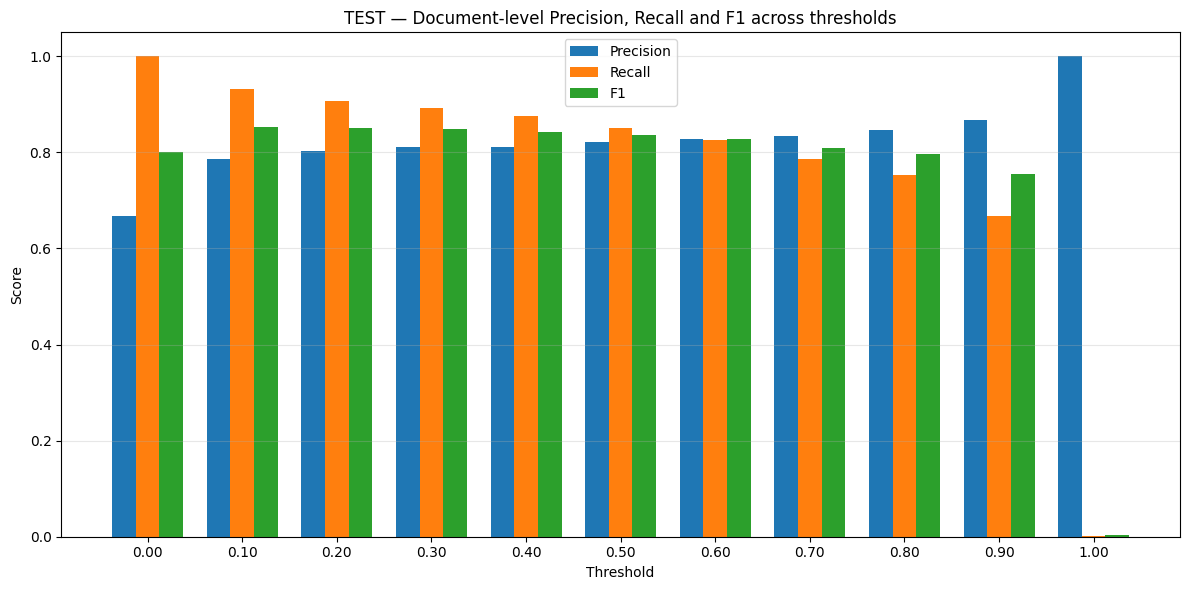

Saved document threshold sweep plot: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/plots/test_document_threshold_sweep_precision_recall_f1.png


In [25]:
# ============================================================
# Bar plot: document-level Precision, Recall and F1 per threshold
# ============================================================

x = np.arange(len(thr_sweep_df))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, thr_sweep_df["precision"], width, label="Precision")
plt.bar(x, thr_sweep_df["recall"], width, label="Recall")
plt.bar(x + width, thr_sweep_df["f1"], width, label="F1")

plt.xticks(
    x,
    [f"{t:.2f}" for t in thr_sweep_df["threshold"]],
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("TEST — Document-level Precision, Recall and F1 across thresholds")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

thr_plot_path = DIR_PLOTS / "test_document_threshold_sweep_precision_recall_f1.png"
plt.savefig(thr_plot_path, dpi=200)
plt.show()

print("Saved document threshold sweep plot:", thr_plot_path)

In [26]:
# ===============================================================
# Pixel-level threshold sweep using existing inference function
# ===============================================================

PIX_THR_SWEEP = np.arange(0.0, 1.01, 0.01)

pixel_thr_rows = []

DIR_CMS_PIX_THR = DIR_CMS / "pixel_threshold_sweep"
DIR_CMS_PIX_THR.mkdir(parents=True, exist_ok=True)

for thr in tqdm(PIX_THR_SWEEP, desc="Pixel-level threshold sweep on test set"):
    thr = float(thr)

    test_res_thr = infer_stitch_save_and_cm_dual_branch(
        runner=runner,
        dl=dl_test,
        ds=ds_test,
        device=DEVICE,
        thr_pix=thr,
        pred_masks_dir=None,
        save_masks=False,
    )

    cm = test_res_thr["pix_cm"]["all"]
    metrics = pix_metrics(cm)

    row = {
        "threshold": round(float(thr), 2),
        "tp": cm["tp"],
        "fp": cm["fp"],
        "fn": cm["fn"],
        "tn": cm["tn"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "iou": metrics["iou"],
    }

    pixel_thr_rows.append(row)

    thr_str = f"{thr:.2f}".replace(".", "p")

    save_cm_png(
        cm_to_array(cm),
        title=f"Pixel CM — threshold={thr:.2f}",
        out_path=DIR_CMS_PIX_THR / f"cm_pixel_thr_{thr_str}.png",
    )

pixel_thr_sweep_df = pd.DataFrame(pixel_thr_rows)

csv_path_pix_thr, png_path_pix_thr = save_csv_and_png_table(
    df=pixel_thr_sweep_df,
    out_dir=DIR_TABLE,
    csv_name="test_pixel_threshold_sweep_metrics.csv",
    png_name="test_pixel_threshold_sweep_metrics.png",
    title="TEST — Pixel-level threshold sweep metrics",
)

print("Saved pixel threshold sweep CSV:", csv_path_pix_thr)
print("Saved pixel threshold sweep PNG:", png_path_pix_thr)
print("Saved pixel threshold CMs in:", DIR_CMS_PIX_THR)

pixel_thr_sweep_df

Pixel-level threshold sweep on test set:   0%|                                                   | 0/30 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, 

Saved pixel threshold sweep CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_metrics.csv
Saved pixel threshold sweep PNG: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_metrics.png
Saved pixel threshold CMs in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/confusion_matrices/pixel_threshold_sweep


,threshold,tp,fp,fn,tn,precision,recall,f1,iou
0,0.00,9298662,1282436997,0,0,0.007199,1.000000,0.014294,0.007199
1,0.01,2156433,3333299,7142229,1279103698,0.392812,0.231908,0.291639,0.170712
2,0.02,2111793,3055501,7186869,1279381496,0.408685,0.227107,0.291967,0.170938
3,0.03,2089039,2925875,7209623,1279511122,0.416565,0.224660,0.291896,0.170889
4,0.04,2074075,2844973,7224587,1279592024,0.421642,0.223051,0.291759,0.170795
5,0.05,2062692,2785889,7235970,1279651108,0.425422,0.221827,0.291603,0.170688
6,0.06,2053251,2739463,7245411,1279697534,0.428411,0.220811,0.291420,0.170562
7,0.07,2045250,2701249,7253412,1279735748,0.430897,0.219951,0.291239,0.170439
8,0.08,2038276,2668619,7260386,1279768378,0.433040,0.219201,0.291067,0.170321
9,0.09,2032139,2640243,7266523,1279796754,0.434926,0.218541,0.290907,0.170212


In [27]:
# ===============================================================
# Pixel-level threshold sweep: zoom between 0.00 and 0.05
# ===============================================================

PIX_THR_SWEEP_ZOOM = np.arange(0.0, 0.051, 0.005)

pixel_thr_zoom_rows = []

DIR_CMS_PIX_THR_ZOOM = DIR_CMS / "pixel_threshold_sweep_zoom_0_005"
DIR_CMS_PIX_THR_ZOOM.mkdir(parents=True, exist_ok=True)

for thr in tqdm(PIX_THR_SWEEP_ZOOM, desc="Pixel-level threshold sweep 0.00-0.05"):
    thr = float(thr)

    test_res_thr = infer_stitch_save_and_cm_dual_branch(
        runner=runner,
        dl=dl_test,
        ds=ds_test,
        device=DEVICE,
        thr_pix=thr,
        pred_masks_dir=None,
        save_masks=False,
    )

    cm = test_res_thr["pix_cm"]["all"]
    metrics = pix_metrics(cm)

    row = {
        "threshold": round(thr, 3),
        "tp": cm["tp"],
        "fp": cm["fp"],
        "fn": cm["fn"],
        "tn": cm["tn"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "iou": metrics["iou"],
    }

    pixel_thr_zoom_rows.append(row)

    thr_str = f"{thr:.3f}".replace(".", "p")

    save_cm_png(
        cm_to_array(cm),
        title=f"Pixel CM — threshold={thr:.3f}",
        out_path=DIR_CMS_PIX_THR_ZOOM / f"cm_pixel_thr_{thr_str}.png",
    )

pixel_thr_zoom_df = pd.DataFrame(pixel_thr_zoom_rows)

csv_path_pix_thr_zoom, png_path_pix_thr_zoom = save_csv_and_png_table(
    df=pixel_thr_zoom_df,
    out_dir=DIR_TABLE,
    csv_name="test_pixel_threshold_sweep_zoom_0_005_metrics.csv",
    png_name="test_pixel_threshold_sweep_zoom_0_005_metrics.png",
    title="TEST — Pixel-level threshold sweep metrics [0.00, 0.05]",
)

print("Saved pixel threshold zoom CSV:", csv_path_pix_thr_zoom)
print("Saved pixel threshold zoom PNG:", png_path_pix_thr_zoom)
print("Saved pixel threshold zoom CMs in:", DIR_CMS_PIX_THR_ZOOM)

pixel_thr_zoom_df

Pixel-level threshold sweep 0.00-0.05:   0%|                                                     | 0/11 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/guests3/rma/.conda/envs/rtm/lib/python3.8/multiprocessing/util.py", line 300, 

Saved pixel threshold zoom CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_zoom_0_005_metrics.csv
Saved pixel threshold zoom PNG: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_zoom_0_005_metrics.png
Saved pixel threshold zoom CMs in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/confusion_matrices/pixel_threshold_sweep_zoom_0_005


,threshold,tp,fp,fn,tn,precision,recall,f1,iou
0,0.000,9298662,1282436997,0,0,0.007199,1.000000,0.014294,0.007199
1,0.005,2212649,3754967,7086013,1278682030,0.370776,0.237953,0.289874,0.169505
2,0.010,2156433,3333299,7142229,1279103698,0.392812,0.231908,0.291639,0.170712
3,0.015,2129383,3160748,7169279,1279276249,0.402520,0.228999,0.291920,0.170906
4,0.020,2111793,3055501,7186869,1279381496,0.408685,0.227107,0.291967,0.170938
5,0.025,2099098,2981575,7199564,1279455422,0.413154,0.225742,0.291960,0.170933
6,0.030,2089039,2925875,7209623,1279511122,0.416565,0.224660,0.291896,0.170889
7,0.035,2080989,2881796,7217673,1279555201,0.419319,0.223794,0.291834,0.170847
8,0.040,2074075,2844973,7224587,1279592024,0.421642,0.223051,0.291759,0.170795
9,0.045,2067998,2813483,7230664,1279623514,0.423642,0.222397,0.291675,0.170738


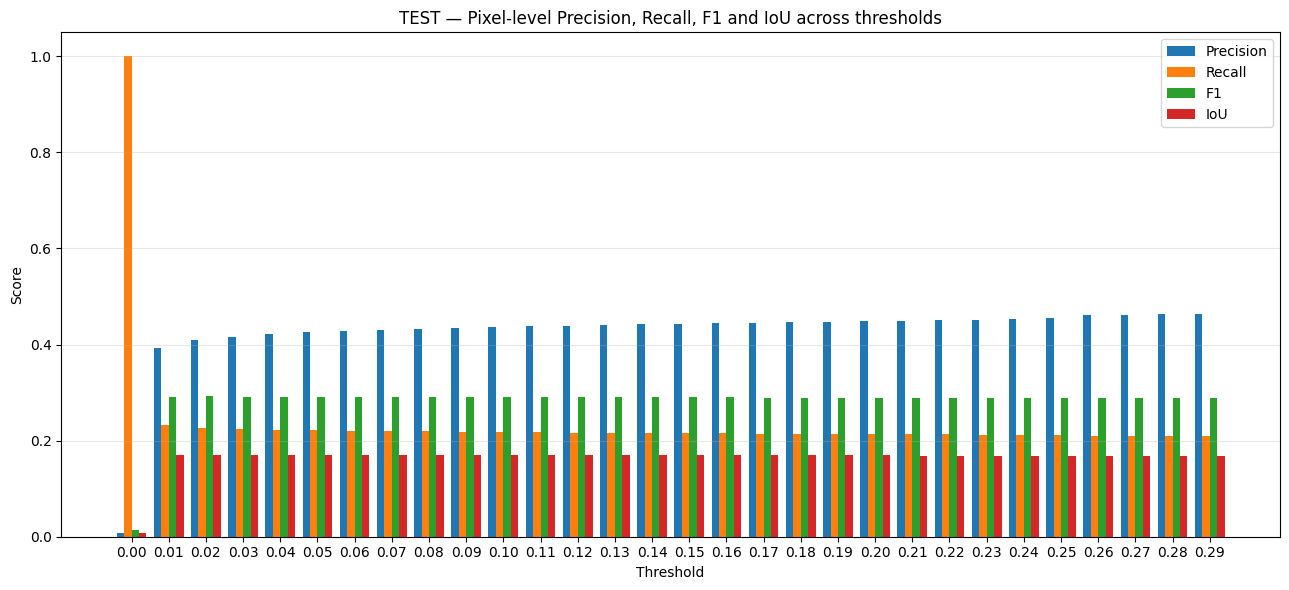

Saved pixel threshold sweep plot: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/plots/test_pixel_threshold_sweep_precision_recall_f1_iou.png


In [28]:
# ====================================================================
# Bar plot: pixel-level Precision, Recall, F1 and IoU per threshold
# ====================================================================

x = np.arange(len(pixel_thr_sweep_df))
width = 0.20

plt.figure(figsize=(13, 6))

plt.bar(x - 1.5 * width, pixel_thr_sweep_df["precision"], width, label="Precision")
plt.bar(x - 0.5 * width, pixel_thr_sweep_df["recall"], width, label="Recall")
plt.bar(x + 0.5 * width, pixel_thr_sweep_df["f1"], width, label="F1")
plt.bar(x + 1.5 * width, pixel_thr_sweep_df["iou"], width, label="IoU")

plt.xticks(
    x,
    [f"{t:.2f}" for t in pixel_thr_sweep_df["threshold"]],
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("TEST — Pixel-level Precision, Recall, F1 and IoU across thresholds")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

pix_thr_plot_path = DIR_PLOTS / "test_pixel_threshold_sweep_precision_recall_f1_iou.png"
plt.savefig(pix_thr_plot_path, dpi=200)
plt.show()

print("Saved pixel threshold sweep plot:", pix_thr_plot_path)

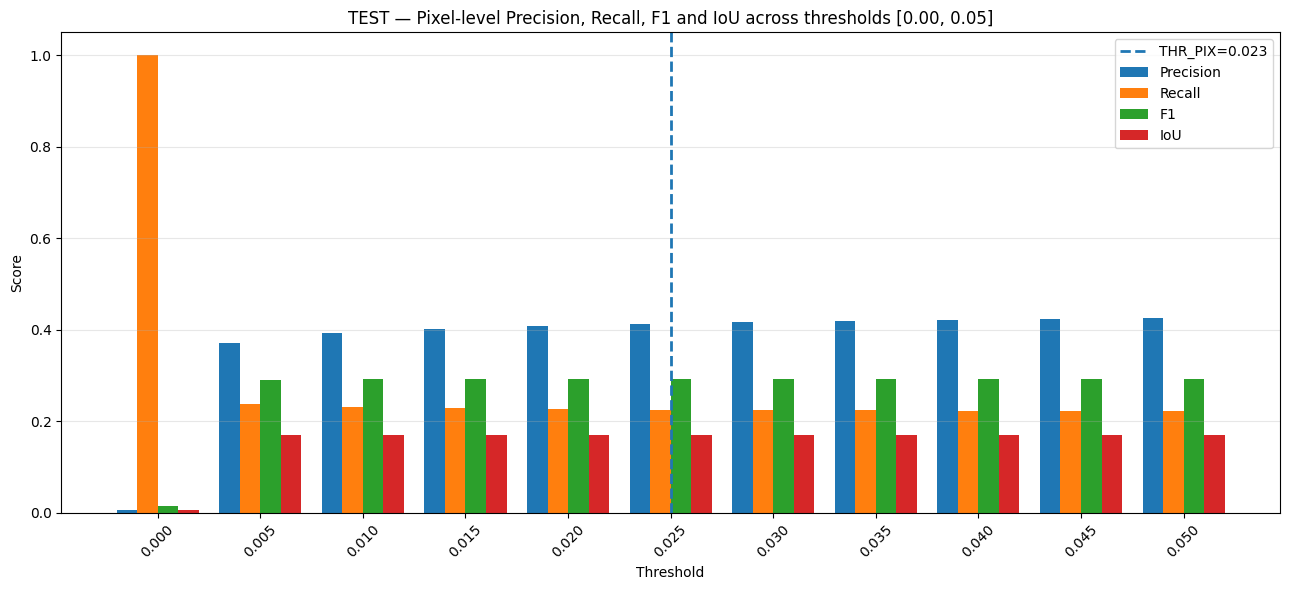

Saved pixel threshold zoom plot: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/plots/test_pixel_threshold_sweep_zoom_0_005_precision_recall_f1_iou.png


In [29]:
# ============================================================
# Bar plot: pixel-level zoom between 0.00 and 0.05
# ============================================================

x = np.arange(len(pixel_thr_zoom_df))
width = 0.20

plt.figure(figsize=(13, 6))

plt.bar(x - 1.5 * width, pixel_thr_zoom_df["precision"], width, label="Precision")
plt.bar(x - 0.5 * width, pixel_thr_zoom_df["recall"], width, label="Recall")
plt.bar(x + 0.5 * width, pixel_thr_zoom_df["f1"], width, label="F1")
plt.bar(x + 1.5 * width, pixel_thr_zoom_df["iou"], width, label="IoU")

plt.axvline(
    x=np.argmin(np.abs(pixel_thr_zoom_df["threshold"].values - float(THR_PIX))),
    linestyle="--",
    linewidth=2,
    label=f"THR_PIX={float(THR_PIX):.3f}",
)

plt.xticks(
    x,
    [f"{float(t):.3f}" for t in pixel_thr_zoom_df["threshold"]],
    rotation=45,
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("TEST — Pixel-level Precision, Recall, F1 and IoU across thresholds [0.00, 0.05]")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

pix_thr_zoom_plot_path = DIR_PLOTS / "test_pixel_threshold_sweep_zoom_0_005_precision_recall_f1_iou.png"
plt.savefig(pix_thr_zoom_plot_path, dpi=200)
plt.show()

print("Saved pixel threshold zoom plot:", pix_thr_zoom_plot_path)

In [30]:
# ==================================================================
# Save document-level confusion matrix values for each threshold
# ==================================================================

DIR_CMS_DOC_THR = DIR_CMS / "document_threshold_sweep"
DIR_CMS_DOC_THR.mkdir(parents=True, exist_ok=True)

doc_cm_rows = []

for thr in tqdm(THR_SWEEP, desc="Saving document-level CMs per threshold"):
    metrics = compute_threshold_metrics_from_scores(
        y_true=df_test_doc["target"].astype(bool).values,
        scores=df_test_doc["score_cls"].values.astype(float),
        threshold=float(thr),
    )

    cm = {
        "tp": metrics["tp"],
        "fp": metrics["fp"],
        "fn": metrics["fn"],
        "tn": metrics["tn"],
    }

    thr_str = f"{float(thr):.2f}".replace(".", "p")

    save_cm_png(
        cm_to_array(cm),
        title=f"Document CM — threshold={float(thr):.2f}",
        out_path=DIR_CMS_DOC_THR / f"cm_document_thr_{thr_str}.png",
    )

    doc_cm_rows.append({
        "threshold": float(thr),
        "tp": cm["tp"],
        "fp": cm["fp"],
        "fn": cm["fn"],
        "tn": cm["tn"],
    })

doc_cm_df = pd.DataFrame(doc_cm_rows)
doc_cm_df.to_csv(DIR_TABLE / "test_document_threshold_sweep_cms.csv", index=False)

print("Saved document-level CMs in:", DIR_CMS_DOC_THR)
print("Saved document CM CSV:", DIR_TABLE / "test_document_threshold_sweep_cms.csv")

Saving document-level CMs per threshold: 100%|██████████████████████████████████████████| 11/11 [00:02<00:00,  3.93it/s]

Saved document-level CMs in: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/confusion_matrices/document_threshold_sweep
Saved document CM CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_document_threshold_sweep_cms.csv


In [31]:
# ============================================================
# Save pixel-level confusion matrix values for each threshold
# ============================================================

pix_cm_df = pixel_thr_sweep_df[
    ["threshold", "tp", "fp", "fn", "tn"]
].copy()

pix_cm_csv_path = DIR_TABLE / "test_pixel_threshold_sweep_cms.csv"
pix_cm_df.to_csv(pix_cm_csv_path, index=False)

print("Saved pixel CM CSV:", pix_cm_csv_path)

Saved pixel CM CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_cms.csv


In [32]:
# ============================================================
# Save pixel-level confusion matrix values for zoom interval
# ============================================================

pix_cm_zoom_df = pixel_thr_zoom_df[
    ["threshold", "tp", "fp", "fn", "tn"]
].copy()

pix_cm_zoom_csv_path = DIR_TABLE / "test_pixel_threshold_sweep_zoom_0_005_cms.csv"
pix_cm_zoom_df.to_csv(pix_cm_zoom_csv_path, index=False)

print("Saved pixel zoom CM CSV:", pix_cm_zoom_csv_path)

Saved pixel zoom CM CSV: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/VAL_TEST/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/tables/test_pixel_threshold_sweep_zoom_0_005_cms.csv


In [33]:
# ============================================================
# TensorBoard training-curve utilities
# ============================================================

def load_tensorboard_scalars(run_dir: Path) -> pd.DataFrame:
    """Load all scalar values from TensorBoard event files into a DataFrame."""
    
    event_files = sorted(run_dir.glob("**/events.out.tfevents.*"))

    rows = []

    for event_file in event_files:
        accumulator = event_accumulator.EventAccumulator(str(event_file))
        accumulator.Reload()

        scalar_tags = accumulator.Tags().get("scalars", [])

        for tag in scalar_tags:
            for event in accumulator.Scalars(tag):
                rows.append(
                    {
                        "file": str(event_file),
                        "tag": tag,
                        "step": event.step,
                        "value": event.value,
                    }
                )

    return pd.DataFrame(rows)


def pick_anchor_tag(
    tag_counts: pd.Series,
    preferred_tags: Optional[List[str]] = None,
    min_points: int = 5,
) -> str:
    """Select a scalar tag used to map TensorBoard steps to epoch indices."""
    
    if preferred_tags is None:
        preferred_tags = [
            "Validation Loss",
            "Validation IMG Precision",
            "Validation IMG Recall",
            "Validation IMG BalAcc",
            "Validation IMG F1",
            "Validation IMG Acc",
            "Training Loss",
            "Training IMG Acc",
            "Training IMG BalAcc",
            "Training IMG F1",
            "Training IMG Precision",
            "Training IMG Recall",
        ]

    for tag in preferred_tags:
        if tag in tag_counts.index and tag_counts[tag] >= min_points:
            return tag

    candidates = tag_counts[tag_counts >= min_points]

    if len(candidates) == 0:
        return str(tag_counts.index[0])

    return str(candidates.index[0])


def add_epoch_column(
    df_scalars: pd.DataFrame,
    epoch_offset: int = 0,
) -> pd.DataFrame:
    """Map TensorBoard steps to epoch indices using a stable anchor tag."""
    
    if df_scalars.empty:
        return df_scalars.copy()

    tag_counts = df_scalars.groupby("tag")["step"].nunique().sort_values(ascending=False)
    anchor_tag = pick_anchor_tag(tag_counts)

    anchor_steps = sorted(df_scalars[df_scalars["tag"] == anchor_tag]["step"].unique())
    step_to_epoch = {step: idx for idx, step in enumerate(anchor_steps)}

    df_epochs = df_scalars.copy()
    df_epochs["epoch"] = df_epochs["step"].map(step_to_epoch)
    df_epochs = df_epochs.dropna(subset=["epoch"]).copy()
    df_epochs["epoch"] = df_epochs["epoch"].astype(int) + epoch_offset

    print("Anchor tag:", anchor_tag)
    print("Number of anchor steps:", len(anchor_steps))
    print("First steps:", anchor_steps[:10])

    return df_epochs


def select_available_metrics(
    df_epochs: pd.DataFrame,
    metrics_of_interest: List[str],
) -> List[str]:
    """Return the requested TensorBoard tags that are available in the run."""
    
    available_tags = set(df_epochs["tag"].unique())

    return [
        tag
        for tag in metrics_of_interest
        if tag in available_tags
    ]


def save_training_metric_plots(
    df_epochs: pd.DataFrame,
    output_dir: Path,
    metrics_of_interest: Optional[List[str]] = None,
) -> pd.DataFrame:
    """Save one line plot per selected TensorBoard metric and export a CSV summary."""
    
    output_dir.mkdir(parents=True, exist_ok=True)

    if EPOCH_MIN is not None:
        df_epochs = df_epochs[df_epochs["epoch"] >= EPOCH_MIN].copy()
    
    if EPOCH_MAX is not None:
        df_epochs = df_epochs[df_epochs["epoch"] < EPOCH_MAX].copy()

    if metrics_of_interest is None:
        metrics_of_interest = [
            "Training Loss",
            "Training precision",
            "Training recall",
            "Training f1-score",
            "Training IMG Precision",
            "Training IMG Recall",
            "Training IMG F1",
            "Training IMG Acc",
            "Training IMG BalAcc",
            "Validation Loss",
            "Validation BestF1",
            "Validation BestThreshold",
            "Validation Precision@UseThr",
            "Validation Recall@UseThr",
            "Validation F1@UseThr",
            "Validation IMG Precision",
            "Validation IMG Recall",
            "Validation IMG F1",
            "Validation IMG Acc",
            "Validation IMG BalAcc",
            "Validation IMG BestThr",
            "Validation IMG BestF1",
        ]

    available_metrics = select_available_metrics(
        df_epochs=df_epochs,
        metrics_of_interest=metrics_of_interest,
    )

    print("Available training metrics:", available_metrics)

    for tag in available_metrics:
        metric_df = df_epochs[df_epochs["tag"] == tag].sort_values("epoch")
    
        plt.figure(figsize=(8, 4))
        plt.plot(metric_df["epoch"], metric_df["value"], marker="o")

        # the training code saves the best checkpoint using Validation BestF1 (Best pixel-level segmentation F1)
        # therefore, only this plot receives the fixed-epoch and best-epoch highlights
        if tag == "Validation BestF1":

            # fixed epoch highlight (red)
            highlight_epoch = 35
            point = metric_df[metric_df["epoch"] == highlight_epoch]

            if not point.empty:
                highlight_value = point["value"].iloc[0]

                plt.plot(
                    highlight_epoch,
                    highlight_value,
                    marker="o",
                    color="red",
                    markersize=8,
                    linestyle="None",
                    label=f"Epoch {highlight_epoch}",
                    zorder=5,
                )

            # best value in the plot (green highlight)
            best_idx = metric_df["value"].idxmax()

            best_epoch = metric_df.loc[best_idx, "epoch"]
            best_value = metric_df.loc[best_idx, "value"]

            plt.plot(
                best_epoch,
                best_value,
                marker="o",
                color="green",
                markersize=8,
                linestyle="None",
                label=f"Best Epoch {best_epoch}",
                zorder=6,
            )

            plt.legend()
    
        plt.title(tag)
        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.grid(True)

        if EPOCH_MIN is not None or EPOCH_MAX is not None:
            plt.xlim(
                left=EPOCH_MIN if EPOCH_MIN is not None else df_epochs["epoch"].min(),
                right=(EPOCH_MAX - 1) if EPOCH_MAX is not None else df_epochs["epoch"].max(),
            )

        safe_name = (
            tag.replace(" ", "_")
            .replace("/", "_")
            .replace("@", "at")
        )

        plt.savefig(
            output_dir / f"{safe_name}.png",
            dpi=200,
            bbox_inches="tight",
        )
        plt.close()

    summary = (
        df_epochs.pivot_table(
            index="epoch",
            columns="tag",
            values="value",
            aggfunc="last",
        )
        .sort_index()
    )

    summary_path = output_dir.parent / "training_metrics_per_epoch.csv"
    summary.to_csv(summary_path)

    print("Saved training plots to:", output_dir)
    print("Saved training CSV to:", summary_path)

    return summary


def export_training_curves(
    run_dir: Path,
    output_dir: Path,
    epoch_offset: int = 0,
) -> pd.DataFrame:
    """Load TensorBoard scalars, create training plots, and save the per-epoch CSV."""
    
    df_scalars = load_tensorboard_scalars(run_dir)

    if df_scalars.empty:
        print("No TensorBoard scalar events found in:", run_dir)
        return pd.DataFrame()

    print("TensorBoard scalar rows:", len(df_scalars))
    print("Unique scalar tags:", df_scalars["tag"].nunique())

    df_epochs = add_epoch_column(
        df_scalars=df_scalars,
        epoch_offset=epoch_offset,
    )

    return save_training_metric_plots(
        df_epochs=df_epochs,
        output_dir=output_dir,
    )


export_training_curves(
    run_dir=RUN_DIR,
    output_dir=TRAIN_PLOTS_DIR,
    epoch_offset=EPOCH_OFFSET,
)

TensorBoard scalar rows: 15947
Unique scalar tags: 36
Anchor tag: Validation Loss
Number of anchor steps: 88
First steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Available training metrics: ['Training Loss', 'Training precision', 'Training recall', 'Training f1-score', 'Training IMG Precision', 'Training IMG Recall', 'Training IMG F1', 'Training IMG Acc', 'Training IMG BalAcc', 'Validation Loss', 'Validation BestF1', 'Validation BestThreshold', 'Validation Precision@UseThr', 'Validation Recall@UseThr', 'Validation F1@UseThr', 'Validation IMG F1', 'Validation IMG Acc', 'Validation IMG BalAcc', 'Validation IMG BestThr', 'Validation IMG BestF1']
Saved training plots to: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/TRAIN/100 epochs/dual_branch_mmseg_segformer_b2_rgb_with_convs_rtm/training_metric_plots/training_metric_plots
Saved training CSV to: /home/guests3/rma/tese/codigo_tese/detect_forgery_documents/opcao_5/models/eval_outputs_corretoo/TRAIN

tag,Epoch Duration,Running Training Loss,Training F1@UseThr,Training IMG Acc,Training IMG BalAcc,Training IMG F1,Training IMG Precision,Training IMG Recall,Training Loss,Training Precision@UseThr,...,Validation UseThr,Validation_BAL BestF1,Validation_BAL BestThreshold,Validation_BAL IMG Acc,Validation_BAL IMG BalAcc,Validation_BAL IMG F1,Validation_BAL IMG Precision,Validation_BAL IMG Recall,Validation_BAL Loss,Validation_BAL f1@0.5
epoch,,,,,,,,,,,,,,,,,,,,,
50,353.722504,NaN,0.714213,0.836182,0.836330,0.837663,0.822962,0.852899,0.835514,0.805978,...,0.019184,0.275290,0.007061,0.696715,0.697312,0.650500,0.772073,0.562005,1.780881,0.270875
51,359.444489,2.083130,0.720413,0.843579,0.844288,0.834524,0.896946,0.780224,0.779209,0.794324,...,0.011102,0.276974,0.003020,0.719465,0.719043,0.699741,0.746671,0.658362,1.737893,0.291403
52,354.835724,NaN,0.714015,0.835464,0.836374,0.844330,0.791667,0.904498,0.793296,0.761476,...,0.041408,0.281390,0.013122,0.715911,0.716131,0.709340,0.732132,0.687923,1.718031,0.293893
53,355.572357,2.085215,0.744545,0.848894,0.848607,0.856186,0.821485,0.893948,0.739463,0.830178,...,0.041408,0.289955,0.005041,0.710934,0.710234,0.692296,0.728576,0.659458,1.718979,0.294979
54,353.316193,NaN,0.738920,0.853131,0.853174,0.858232,0.828537,0.890135,0.736242,0.824237,...,0.400000,0.270945,0.097980,0.708659,0.708724,0.707912,0.701611,0.714327,1.721750,0.303679
55,355.887207,2.097908,0.744690,0.853131,0.853387,0.862132,0.809675,0.921857,0.723542,0.869909,...,0.043429,0.265568,0.007061,0.698422,0.700178,0.675936,0.748562,0.616156,1.776357,0.276057
56,356.124451,NaN,0.758609,0.872235,0.872335,0.871784,0.882791,0.861048,0.686840,0.827957,...,0.015143,0.305455,0.007061,0.705815,0.705625,0.685036,0.734574,0.641757,1.726313,0.305018
57,354.224792,2.091117,0.750212,0.870583,0.870317,0.877148,0.838941,0.919000,0.704194,0.805705,...,0.019184,0.262933,0.009082,0.716337,0.716013,0.699050,0.739311,0.662947,1.798166,0.279593
58,355.482910,NaN,0.752045,0.859739,0.860448,0.870927,0.801387,0.953684,0.658337,0.808158,...,0.005041,0.261533,0.003020,0.706100,0.706069,0.700652,0.712518,0.689174,1.812921,0.268181
